# Clusters — how many groups the swarm formed

Groups here are the **connected components of the perception graph**, which is the definition
Hénard et al. use:

> Replacing agents with nodes and their neighbours with adjacent nodes makes it possible to define
> a graph that connects the agents. Consequently, if only a disconnected graph with two or more
> components can be obtained, it implies that the swarm is fragmented, because there is no
> coordination or communication possible between the two groups.

Unity computes this every captured frame in `SwarmClusterMetrics` and stores the sizes largest
first, so a frame reads `"k":[27,13]`. The edge test is the same one `SwarmAgent` uses to choose
neighbours — centre to collider edge, under the perception radius — because measuring groups by a
different rule than the agents steer by would report splits the swarm never experienced.

`validate_clusters.py` rebuilds the same graph with `scipy.sparse.csgraph.connected_components`
and compares, the same way `validate_hull.py` checks the areas.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import same_start as sst

RECORDINGS = Path("../../Assets/SimulationRecordings/Combinations/Flocking")

runs = sst.load_folder(RECORDINGS)
inv = sst.inventory(runs)

with_clusters = [r for r in runs if sst.has_clusters(r)]
print(f"{len(runs)} clips, {len(with_clusters)} with cluster data\n")
print(sst.describe(inv))

if not with_clusters:
    print("\n!! These recordings predate cluster capture.")
    print("   Re-record with SwarmTrajectoryRecorder.captureClusters enabled,")
    print("   then re-run this notebook. The next cell derives clusters from the")
    print("   stored positions so the rest still works in the meantime.")

18 clips, 0 with cluster data

random movement : 0, 40, 80
max speed       : 1.5, 4
perception radii: 3 levels, 0.15 to 42.15
                  0.15, 3.15, 42.15
spawn layouts   : 1  (all shared by every condition)

   motion         random  maxSpeed  clips  layouts  radii  R range
   Flocking            0       1.5      3        1      3  0.15-42.15
   Flocking            0       4.0      3        1      3  0.15-42.15
   Flocking           40       1.5      3        1      3  0.15-42.15
   Flocking           40       4.0      3        1      3  0.15-42.15
   Flocking           80       1.5      3        1      3  0.15-42.15
   Flocking           80       4.0      3        1      3  0.15-42.15

!! These recordings predate cluster capture.
   Re-record with SwarmTrajectoryRecorder.captureClusters enabled,
   then re-run this notebook. The next cell derives clusters from the
   stored positions so the rest still works in the meantime.


## Fallback for older recordings

Cluster sizes are stored per frame from now on. Recordings made before that still hold every agent
position, so the same graph can be rebuilt after the fact — slower, but it means an old batch is
not wasted.

This cell is a no-op once the recordings carry `k`.

In [2]:
import json
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

def sizes_from_positions(points, cutoff):
    n = len(points)
    pairs = cKDTree(points).query_pairs(cutoff, output_type="ndarray")
    if len(pairs) == 0:
        return [1] * n
    graph = csr_matrix((np.ones(len(pairs), np.int8), (pairs[:, 0], pairs[:, 1])), shape=(n, n))
    _, labels = connected_components(graph, directed=False)
    return sorted(np.bincount(labels).tolist(), reverse=True)

def backfill(run, every=20):
    """Derive cluster sizes from stored positions, subsampling frames for speed."""
    data = json.loads(run["path"].read_text())
    header = data["header"]
    cutoff = float(header["perceptionRadius"]) + float(header.get("agentRadius", 0.0))
    frames = data["frames"][::every]

    run["times"] = np.array([f["t"] for f in frames])
    run["areas"] = np.array([f.get("a", 0.0) for f in frames])
    run["contacts"] = np.array([len(f.get("c") or []) for f in frames])
    run["unique"] = np.zeros(len(frames), dtype=int)
    run["clusters"] = [sizes_from_positions(
        np.asarray(f["v"], float).reshape(-1, sst.STRIDE)[:, :2], cutoff) for f in frames]
    run["cluster_count"] = np.array([len(k) for k in run["clusters"]])
    run["largest_cluster"] = np.array([k[0] for k in run["clusters"]])
    run["header"] = {**header, "clustersRecorded": True,
                     "clusterPerceptionRadius": header["perceptionRadius"]}
    return run

if not with_clusters:
    runs = [backfill(r) for r in runs]
    print(f"derived cluster sizes for {len(runs)} recordings")
else:
    print("recordings already carry cluster data; nothing to derive")

inv = sst.inventory(runs)
SPEED = inv["speeds"][0]

derived cluster sizes for 18 recordings


## 1. How many groups, over time

One panel per random level, coloured by perception radius. The dashed line at 1 is an intact swarm;
anything above it is fragmented.

`min_size=2` ignores lone agents. Set it to 1 to count a single stray as a group, which is the
paper's reading — it treats losing one robot as fragmentation.

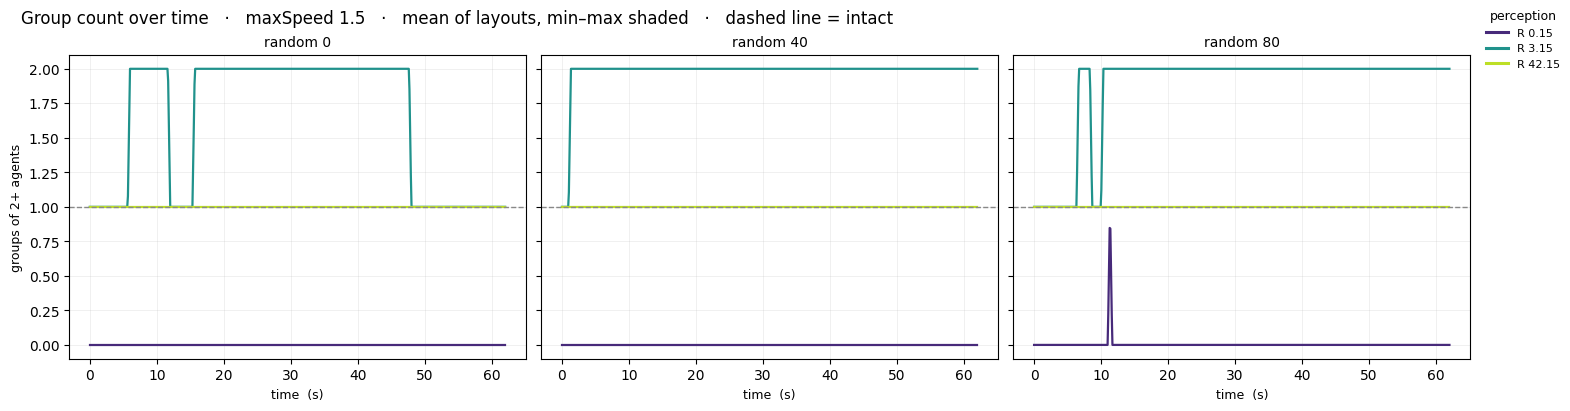

In [3]:
sst.cluster_figure(runs, SPEED, min_size=2)
plt.show()

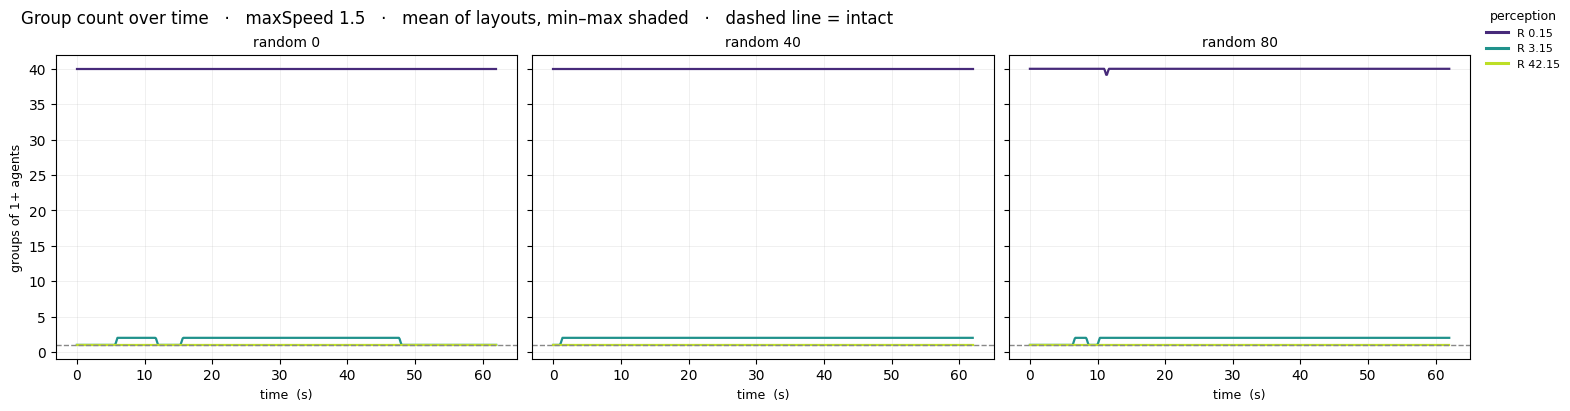

With min_size=1 the smallest radius shows 40 groups: every agent is isolated,
which is not a flock at all rather than a fragmented one.


In [4]:
sst.cluster_figure(runs, SPEED, min_size=1)
plt.show()
print("With min_size=1 the smallest radius shows 40 groups: every agent is isolated,")
print("which is not a flock at all rather than a fragmented one.")

## 2. What the groups were made of

Each bar is one condition, split into its groups with the largest at the bottom. One full bar means
the swarm held together; many thin slices mean it never formed.

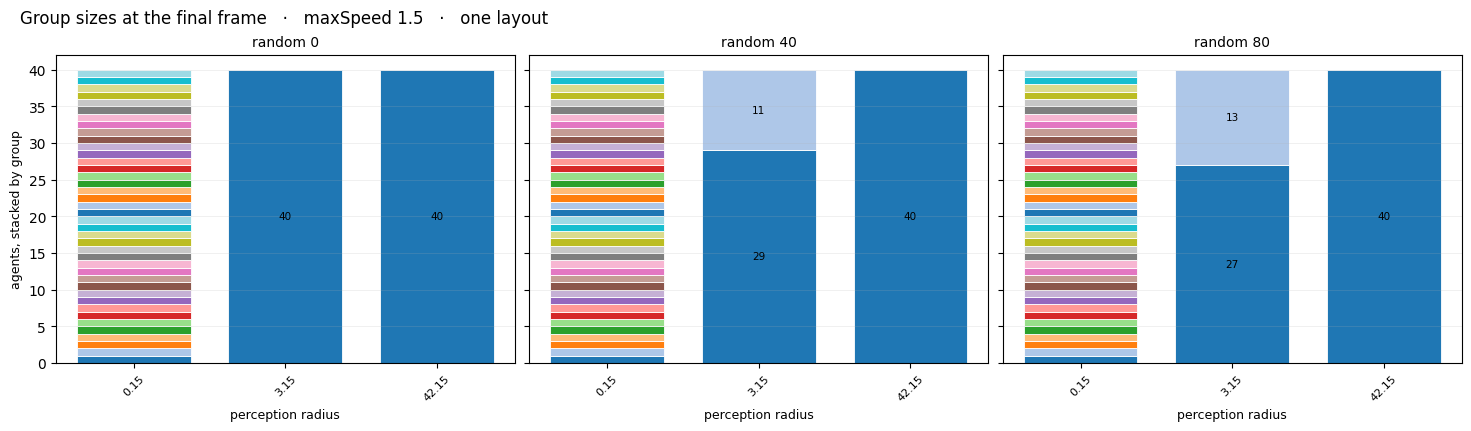

In [5]:
sst.cluster_size_figure(runs, SPEED, frame="final")
plt.show()

## 3. Did the split last?

A group count on a single frame is not a finding. Agents drift in and out of range constantly, so a
swarm can register a split for a handful of frames and rejoin.

`held_fraction` is the share of the second half of the clip spent fragmented. That is what
separates a genuine split from a flicker: a value near 1 means the swarm stayed apart, a value near
0 means the count touched 2 once and recovered.

In [6]:
rows = []
for run in sorted(runs, key=lambda r: (r["R"], r["random"], r["speed"])):
    s = sst.fragmentation_summary(run, min_size=2)
    if not s:
        continue
    rows.append({"R": run["R"], "random": run["random"], "maxSpeed": run["speed"],
                 "groups final": s["groups_final"],
                 "groups max": s["groups_max"],
                 "largest share": round(s["largest_share_final"], 2),
                 "first split (s)": round(s["first_split_s"], 1) if s["first_split_s"] else None,
                 "held fraction": round(s["held_fraction"], 2)})

table = pd.DataFrame(rows)
display(table)

lasting = table[table["held fraction"] > 0.5]
print(f"{len(lasting)} of {len(table)} conditions stayed fragmented for most of the clip.")

,R,random,maxSpeed,groups final,groups max,largest share,first split (s),held fraction
0,0.15,0,1.5,0,0,0.00,NaN,0.00
1,0.15,0,4.0,0,1,0.00,NaN,0.00
2,0.15,40,1.5,0,0,0.00,NaN,0.00
3,0.15,40,4.0,0,1,0.00,NaN,0.00
4,0.15,80,1.5,0,1,0.00,NaN,0.00
5,0.15,80,4.0,1,2,0.05,56.3,0.01
6,3.15,0,1.5,1,2,1.00,6.0,0.54
7,3.15,0,4.0,2,3,0.72,NaN,1.00
8,3.15,40,1.5,2,2,0.72,1.3,1.00
9,3.15,40,4.0,2,4,0.75,4.3,1.00


6 of 18 conditions stayed fragmented for most of the clip.


## 4. Which parameters actually fragment the flock

Averaged over the conditions available, to see where the interesting regime is.

In [7]:
pivot = table.pivot_table(index="R", columns=["maxSpeed", "random"],
                          values="held fraction", aggfunc="mean")
print("fraction of the late clip spent fragmented")
display(pivot)

print("\nRead the extremes as failures of the setup rather than results:")
print("  a radius where every agent is isolated never forms a flock,")
print("  and one where everything is in range can never split.")

fraction of the late clip spent fragmented


maxSpeed   1.5            4.0           
random      0    40   80   0    40    80
R                                       
0.15      0.00  0.0  0.0  0.0  0.0  0.01
3.15      0.54  1.0  1.0  1.0  1.0  0.90
42.15     0.00  0.0  0.0  0.0  0.0  0.00


Read the extremes as failures of the setup rather than results:
  a radius where every agent is isolated never forms a flock,
  and one where everything is in range can never split.


## 5. Cross-check against an independent implementation

`SwarmClusterMetrics` uses union-find with path halving. This rebuilds the same graph with scipy's
connected-components routine — different algorithm, different code — and compares frame by frame.

Once recordings carry `k`, run the same check from the command line across a whole batch:

```bash
python3 validate_clusters.py ../Assets/SimulationRecordings/Combinations/<batch>/
```

In [8]:
def union_find_sizes(points, cutoff):
    """Transliteration of SwarmClusterMetrics: union by rank with path halving."""
    n = len(points)
    parent, rank, size = list(range(n)), [0]*n, [1]*n

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra == rb:
            return
        if rank[ra] < rank[rb]:
            ra, rb = rb, ra
        parent[rb] = ra
        size[ra] += size[rb]
        if rank[ra] == rank[rb]:
            rank[ra] += 1

    for i in range(n):
        for j in range(i + 1, n):
            if float(np.hypot(*(points[i] - points[j]))) < cutoff:
                union(i, j)

    return sorted((size[i] for i in range(n) if find(i) == i), reverse=True)

checked = mismatched = 0
for run in runs[:6]:
    data = json.loads(run["path"].read_text())
    cutoff = (float(data["header"]["perceptionRadius"])
              + float(data["header"].get("agentRadius", 0.0)))
    for f in data["frames"][::400]:
        pts = np.asarray(f["v"], float).reshape(-1, sst.STRIDE)[:, :2]
        checked += 1
        if union_find_sizes(pts, cutoff) != sizes_from_positions(pts, cutoff):
            mismatched += 1

print(f"frames compared : {checked}")
print(f"mismatches      : {mismatched}")
print("PASS" if mismatched == 0 else "FAIL")

frames compared : 60
mismatches      : 0
PASS


## Notes

- **Singletons.** `min_size=1` counts a lone agent as a group, matching the paper's "the swarm
  loses one or more robots". `min_size=2` asks the different question of how many actual flocks
  formed. Both are shown above because they answer different things.
- **The perception radius is the measurement.** Group membership is defined by that radius, so
  sweeping it changes what counts as a group as well as how the swarm behaves. A radius large
  enough to span the arena can never register a split.
- **Frame-level counts are noisy.** Prefer `held_fraction` over `groups_final` when deciding
  whether a condition fragments.
- **Layouts.** Each motion type spawns in its own area, so layouts captured for Dispersion do not
  suit Flocking. `SimRecorder` now warns on a mismatch and captures fresh ones when none are
  named.